In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Requirement Analysis/cleaned_dataset.csv")
df.head()

,sentence,label
0,the system shall refresh the display every 60 ...,1
1,the application shall match the color of the s...,1
2,if projected the data must be readable on a ...,1
3,the product shall be available during normal b...,1
4,if projected the data must be understandable ...,1


## **Basic Information of Data**

In [6]:
print(df.shape)


(11533, 2)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11533 entries, 0 to 11532
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  11533 non-null  object
 1   label     11533 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 180.3+ KB
None


In [8]:
print(df.describe())

              label
count  11533.000000
mean       0.204457
std        0.403322
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000


# **Class Distribution**

In [9]:
print(df["label"].value_counts())

label
0    9175
1    2358
Name: count, dtype: int64


## **Sentence Length Analysis**

In [10]:
df["length"] = df["sentence"].apply(lambda x: len(x.split()))
print(df["length"].describe())

count    11533.000000
mean        18.837423
std         20.868201
min          1.000000
25%          9.000000
50%         16.000000
75%         24.000000
max       1535.000000
Name: length, dtype: float64


# **Most Common Words**

In [11]:
from collections import Counter

all_words = " ".join(df["sentence"]).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('the', 18006), ('to', 7266), ('of', 6561), ('and', 5460), ('a', 5176), ('or', 4254), ('for', 3450), ('in', 2965), ('that', 1840), ('system', 1803), ('is', 1803), ('be', 1799), ('should', 1757), ('by', 1623), ('information', 1608), ('health', 1556), ('with', 1503), ('shall', 1486), ('an', 1412), ('solution', 1372)]


# **Data Visualization**

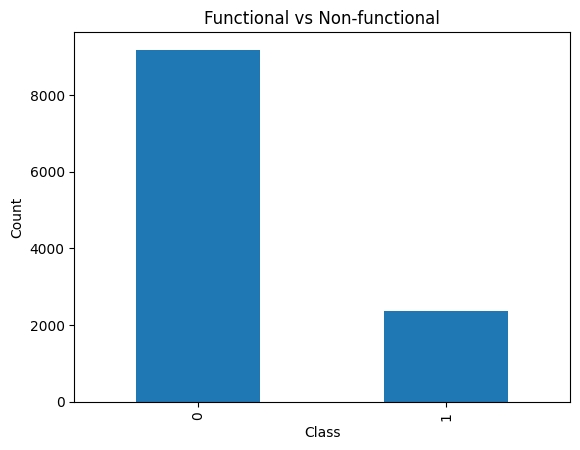

In [12]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Functional vs Non-functional")
plt.show()

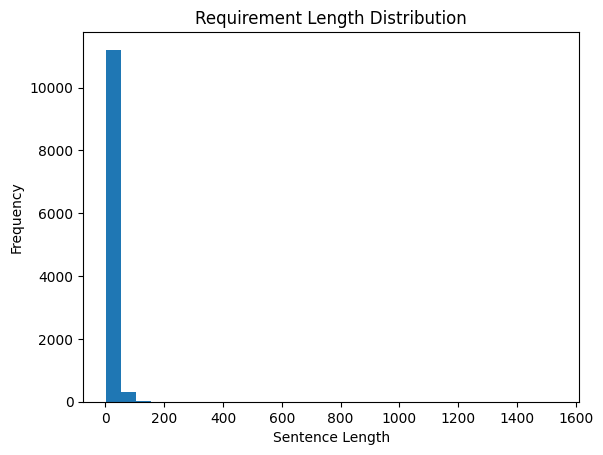

In [13]:
df["length"].plot(kind="hist", bins=30)
plt.xlabel("Sentence Length")
plt.title("Requirement Length Distribution")
plt.show()

# **Feature Selection**

# **TF-IDF (Feature Engineering)**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["sentence"])
y = df["label"]

In [16]:
features = vectorizer.get_feature_names_out()

print(features[:50])

['000' '10' '100' '11' '12' '14' '15' '16' '170299' '20' '2000' '2002'
 '2012' '21' '23' '30' '4010' '42' '45' '50' '60' '80' '90' 'ability'
 'able' 'about' 'access' 'accessed' 'accessible' 'accordance' 'according'
 'account' 'accounting' 'accounts' 'accreditation' 'act' 'action'
 'actions' 'active' 'activities' 'activity' 'add' 'added' 'addition'
 'additional' 'address' 'administered' 'administration' 'administrative'
 'administrator']


# **Chi-Square**

In [17]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=500)
X_selected = selector.fit_transform(X, y)

print(X_selected.shape)

(11533, 500)


# **Clustering and Cluster Analysis**

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

In [19]:
df["cluster"] = clusters

In [20]:
print(df["cluster"].value_counts())

cluster
1    6734
2    3086
0    1713
Name: count, dtype: int64


In [21]:
for i in range(3):
    print(f"\nCluster {i}")
    print(df[df["cluster"] == i]["sentence"].head(5))


Cluster 0
30     the disputes system must provide the ability t...
33     the disputes system shall provide the users th...
222    the website should have an african feel  but s...
223    the website design should be modern  clean  an...
276    the website should cater to all tribes in nigeria
Name: sentence, dtype: object

Cluster 1
0    the system shall refresh the display every 60 ...
2    if projected  the data must be readable  on a ...
3    the product shall be available during normal b...
5    the product shall ensure that it can only be a...
6    the product shall be intuitive and selfexplana...
Name: sentence, dtype: object

Cluster 2
1     the application shall match the color of the s...
4     if projected  the data must be understandable ...
8     the system shall have a mdi form that allows f...
22    the disputes system will provide the user the ...
23    the disputes system must allow the user to cre...
Name: sentence, dtype: object
